# How it works
This project is a real-time emotion recognition detector using computer vision.
The specif library requirements for this project are available in the requirements.txt file

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace

print("✅ Todo funcionando con el kernel Smiler!") #Kernel working

✅ Todo funcionando con el kernel Smiler!


First: printing an image to check that cv2 is working properly

In [13]:
img = cv2.imread("C:/Users/Jose Fernando Barros/sisonreir/happy-people12.jpg")

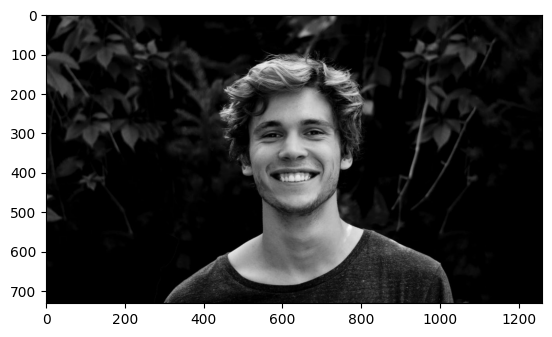

In [14]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

## Emotion Detection
Second, using DeepFace to retrieve several information from the image,
Note: the first time it runs it'll take some time, since we have to download multiple pre-trained models from the internet

In [16]:
predictions = DeepFace.analyze(img)

Action: race: 100%|██████████████████████████████████████████████████████████████████████| 4/4 [00:03<00:00,  1.29it/s]


In [17]:
predictions

[{'emotion': {'angry': 2.9062895289694723e-07,
   'disgust': 5.308091170116181e-20,
   'fear': 0.09897131224318596,
   'happy': 0.024305796263607293,
   'sad': 99.80950953847056,
   'surprise': 2.2302074992927883e-12,
   'neutral': 0.0672059169948498},
  'dominant_emotion': 'sad',
  'region': {'x': 487, 'y': 188, 'w': 288, 'h': 288},
  'age': 32,
  'gender': {'Woman': 1.5914184972643852, 'Man': 98.40857982635498},
  'dominant_gender': 'Man',
  'race': {'asian': 13.52556198835373,
   'indian': 21.20678871870041,
   'black': 3.7800703197717667,
   'white': 11.550811678171158,
   'middle eastern': 16.960005462169647,
   'latino hispanic': 32.97675848007202},
  'dominant_race': 'latino hispanic'}]

In [18]:
type(predictions)

list

In [19]:
print(predictions[0].keys())  #Let's see the keys

dict_keys(['emotion', 'dominant_emotion', 'region', 'age', 'gender', 'dominant_gender', 'race', 'dominant_race'])


In [20]:
dominant_emotion = predictions[0]['dominant_emotion']  #Accesing the emotion of the  image
print(dominant_emotion)


sad


## Creating a rectangle around the faces
For this purpose, the Haarcascade XML file is used, it is a cascade classifier that basically uses set of rules trained to recognize faces using Haar features (patterns like edges, textures, etc.)

In [22]:
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [23]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = faceCascade.detectMultiScale(gray, 1.1,4)
#scaleFactor: reduce la imagen en cada paso. 1.1 significa que reduce en un 10%. Es como hacer zoom hacia afuera para buscar caras de distintos tamaños.
#	minNeighbors: cuántas detecciones consecutivas se necesitan para confirmar que sí es una cara. A mayor valor, menos falsos positivos pero más probable que se te escape alguna cara.
for(x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
#scaleFactor: Reduces the image at each step. 1.1 means a 10% reduction. It's like zooming out to find faces of different sizes.
#minNeighbors: How many consecutive detections are needed to confirm it's a face. The higher the value, the fewer false positives, but the more likely you are to miss a face.

Recorre todos los rostros detectados.

Dibuja un rectángulo verde ((0, 255, 0)) sobre la imagen original (img) donde se encontró cada rostro.

(x, y) : esquina superior izquierda.

(x+w, y+h) : esquina inferior derecha.

2 : grosor de la línea.

faces is a list of tuples containing the coordinates (x, y, w, h) of each detected face.

x, y: Coordinates of the upper-left corner.

w, h: Width and height of the rectangle enclosing the face.

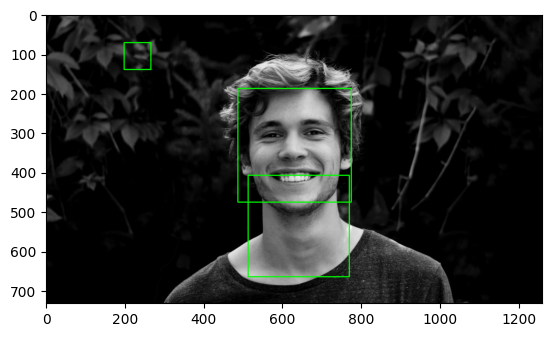

In [25]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [26]:
img2= cv2.imread("C:/Users/Jose Fernando Barros/sisonreir/reich.jpg")

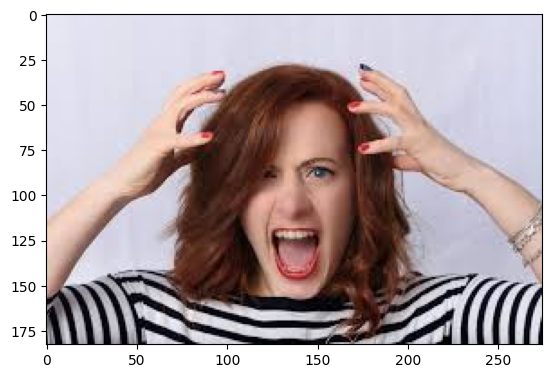

In [27]:
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))

In [28]:
gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

faces = faceCascade.detectMultiScale(gray, 1.1,4)
for(x, y, w, h) in faces:
    cv2.rectangle(img2, (x, y), (x+w, y+h), (0, 255, 0), 2)

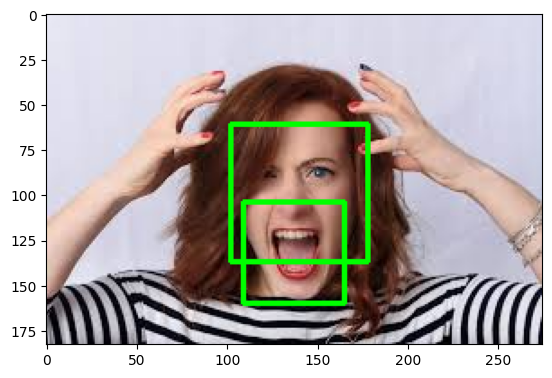

In [29]:
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))

## Adding text 
The text will show the emotion retrieved by DeepFace and will follow the location of the rectangle 

In [31]:
font = cv2.FONT_HERSHEY_SIMPLEX 
cv2.putText(img, 
            predictions[0]['dominant_emotion'],
            (50,50),
            font, 1, 
            (123, 255, 255),
            2, cv2.LINE_4) ;

In [32]:
'''
cv2.putText(img3, 
            predictions[0]['dominant_emotion'],
            (0,50), #Coordinates in the image
            font, 1, #fontsize
            (123, 255, 255), #RGB
            2, #letter thickness
            cv2.LINE_4) ;  #Line type used to draw the outline of the letters. LINE_4 = antialiased line (smooth and thick)
            '''

"\ncv2.putText(img3, \n            predictions[0]['dominant_emotion'],\n            (0,50), #Coordinates in the image\n            font, 1, #fontsize\n            (123, 255, 255), #RGB\n            2, #letter thickness\n            cv2.LINE_4) ;  #Line type used to draw the outline of the letters. LINE_4 = antialiased line (smooth and thick)\n            "

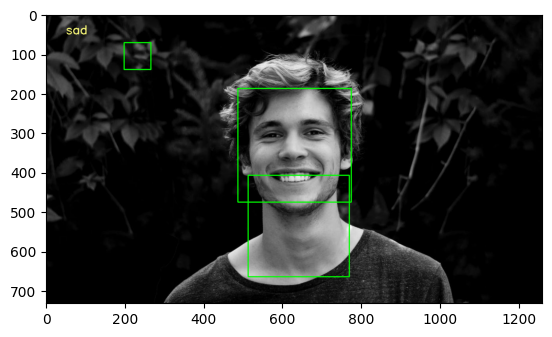

In [33]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

## Todo el proceso, pero con otra imagen/ All the process again, but with another image

In [35]:
img3 = cv2.imread("C:/Users/Jose Fernando Barros/sisonreir/japi.jpg")

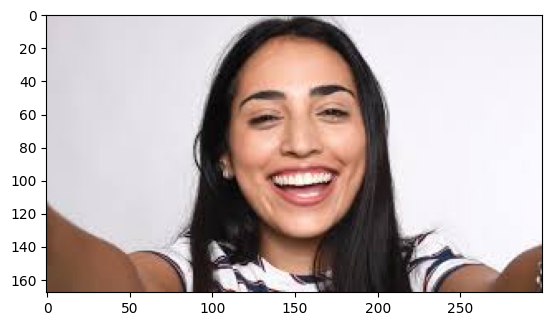

In [36]:
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
plt.imshow(img3)

In [37]:
predictions = DeepFace.analyze(img3)

Action: race: 100%|██████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  2.70it/s]


In [38]:
new_pred = predictions

In [39]:
dominant_emotion = new_pred[0]['dominant_emotion']
print(dominant_emotion)


happy


In [40]:
gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

faces = faceCascade.detectMultiScale(gray, 1.1,4) #Use the Haar Cascade (faceCascade) model to detect faces in the grayscale image
for(x, y, w, h) in faces:
    cv2.rectangle(img3, (x, y), (x+w, y+h), (0, 255, 0), 2)

In [41]:
font = cv2.FONT_HERSHEY_SIMPLEX 
cv2.putText(img3, 
            predictions[0]['dominant_emotion'],
            (0,50),
            font, 1, 
            (123, 255, 255),
            2, cv2.LINE_4) ;

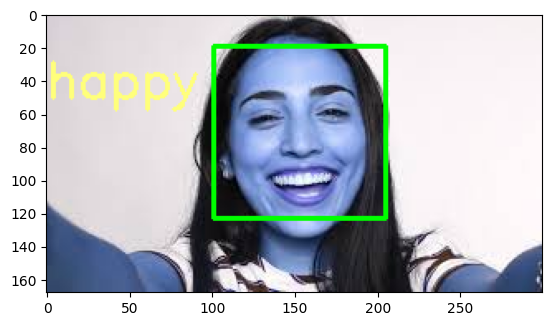

In [42]:
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))

# Real time emotion classifier

In [47]:
import cv2
from deepface import DeepFace

# First step: Load the Haar classifier to detect faces
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
font = cv2.FONT_HERSHEY_SIMPLEX

# Second step: initializing the camera
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    cap = cv2.VideoCapture(1)
if not cap.isOpened():
    raise IOError('Not possible opening the webcam')

while True:
    ret, frame = cap.read()
    if not ret:
        print("Frame unreadable")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        # Extracting the face from the frame
        face_img = frame[y:y+h, x:x+w]

        try:
            result = DeepFace.analyze(face_img, actions=['emotion'], enforce_detection=False)
            emotion = result[0]['dominant_emotion']
        except:
            emotion = "?"
#If something goes wrong, instead of throwing an error that would stop the program, simply assign "?" as the emotion.
        
        # Drawing the rectangle and showing the emotion (as text)
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, emotion, (x, y - 10), font, 0.9, (255, 255, 0), 2, cv2.LINE_AA)

    # Showing the image's emotion
    cv2.imshow('Webcam - Emotion Detection', frame)
#cv2.imshow() opens a real-time display window.
#'Webcam - Emotion Detection' is the name of that window.
#frame is the current image captured by the webcam.

    if cv2.waitKey(2) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.49it/s]


In [49]:
#For checking which camera is the one that we have to use
for i in range(3):
    cap = cv2.VideoCapture(i)
    if cap.isOpened():
        print(f"The camera that works is {i}")
        cap.release()
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)  

The camera that works is 0


## Optional: registering the emotions in a CSV by datetime 


In [51]:
import cv2
from deepface import DeepFace
import csv
from datetime import datetime  

# First step: Load the Haar classifier to detect faces
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
font = cv2.FONT_HERSHEY_SIMPLEX

# Creating a CSV writing (and naming) the headers
log_file = open('emotion_log.csv', mode='w', newline='')
log_writer = csv.writer(log_file)
log_writer.writerow(['Timestamp', 'Emotion'])

# Second step: initializing the camera
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    cap = cv2.VideoCapture(1)
if not cap.isOpened():
    raise IOError('Not possible opening the webcam')

while True:
    ret, frame = cap.read()
    if not ret:
        print("Frame unreadable")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        # Extracting the face from the frame
        face_img = frame[y:y+h, x:x+w]

        try:
            result = DeepFace.analyze(face_img, actions=['emotion'], enforce_detection=False)
            emotion = result[0]['dominant_emotion']
        except:
            emotion = "?"

        # Saving the emotion and the timestamp in the CSV
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        log_writer.writerow([timestamp, emotion])

        # Drawing the rectangle and showing the emotion (as text)
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(frame, emotion, (x, y - 10), font, 0.9, (255, 255, 0), 2, cv2.LINE_AA)

    # Showing the image's emotion
    cv2.imshow('Webcam - Emotion Detection', frame)

    #Exit the detection by pressing the 'q' key 
    if cv2.waitKey(2) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
log_file.close()  # Closing the file when finalizing the detection Cerrar el archivo CSV al finalizar


Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.04it/s]


In [55]:
#Checking the exact direction in which the CSV was saved
import os

log_path = os.path.abspath('emotion_log.csv')
print(f"CSV saved here: {log_path}")


CSV saved here: C:\Users\Jose Fernando Barros\sisonreir\emotion_log.csv


## Checking the CSV with the emotions

In [59]:
import pandas as pd

In [63]:
df = pd.read_csv('emotion_log.csv')

In [65]:
df.head(10)

,Timestamp,Emotion
0,2025-06-17 06:27:20,neutral
1,2025-06-17 06:27:20,sad
2,2025-06-17 06:27:20,neutral
3,2025-06-17 06:27:21,neutral
4,2025-06-17 06:27:21,neutral
5,2025-06-17 06:27:21,sad
6,2025-06-17 06:27:21,sad
7,2025-06-17 06:27:22,happy
8,2025-06-17 06:27:22,fear
9,2025-06-17 06:27:22,fear
